# Commitment issues

**Inspired by:** de Font‐Reaulx, P. (2026). Do expected utility maximizers have commitment issues? _Philosophy and Phenomenological Research,_ 112(1), 3-23.

In [1]:
from memo import memo
from enum import IntEnum
from jax import numpy as np
from jax.scipy.stats.bernoulli import pmf as ber
from typing import no_type_check

Start with preliminary definitions taken directly from paper.

In [2]:
class DayAction(IntEnum):
    SH = 0
    GO = 1

class NightAction(IntEnum):
    Retire = 0
    Party = 1

class NightType(IntEnum):
    Responsible = 0
    Fun = 1

P = np.linspace(0, 1, 101)


g, b = 1.0, 1.0
e, l = 1.0, 2.0

def one_night_payoff(night_action):
    return np.array([e, l])[night_action]

def one_day_payoff(day_action, night_action):
    return np.array([
        [+0, +0],
        [+g, -b]
    ])[day_action, night_action]

Model of daytime Penelope. She has prior $p$ over her night self being fun (note: opposite convention from paper). Her night self then chooses an action depending on her policy (to be defined later). Then, based on what she learns, she repeats again tomorrow.

In [3]:
@no_type_check
@memo(cache=True)
def day_model[p: P, da: DayAction](n=0):
    day: knows(p, da)
    day: thinks[
        night: knows(p),
        night: given(t in NightType, wpp=ber(t, p)),
        night: chooses(
            na in NightAction,
            wpp=
            (na == {NightAction.Retire})
            if t == {NightType.Responsible} else
            ber(na, night_model[0][p](n))
        )
    ]
    day: snapshots_self_as(next_day)
    return day[E[one_day_payoff(da, night.na)] + (0 if n <= 0 else imagine[
        next_day: observes [night.na] is night.na,
        next_day: chooses(
            p_ in P,
            to_minimize=abs(p_ - Pr[night.t == {NightType.Fun}])
        ),
        next_day: chooses(
            da_ in DayAction,
            to_maximize=day_model[p_, da_](n - 1)
        ),
        E[next_day[ day_model[p_, da_](n - 1) ]]
    ])]

Night Penelope wants to maximize her payoff. She chooses a mixed strategy by picking a $\sigma$ that maximizes the informativity to her future day self. Day self then updates belief based on the action taken, which affects future payoff.

In [4]:
@no_type_check
@memo(cache=True)
def night_model[p: P](n=0):
    night: knows(p)
    night: wants(
        payoff=
        one_night_payoff(na) +
        (0 if n <= 0 else E[night_model[1][p](n - 1) if day.da_ == {DayAction.GO} else 0])
    )
    night: chooses(sigma in P, to_maximize=EU[payoff])
    night: chooses(na in NightAction, wpp=ber(na, sigma))
    night: thinks[
        day: knows(p, sigma),
        day: thinks[
            night: knows(p, sigma),
            night: given(t in NightType, wpp=ber(t, p)),
            night: chooses(
                na in NightAction,
                wpp=(na == {NightAction.Retire}) if t == {NightType.Responsible} else ber(na, sigma)
            )
        ],
        day: observes [night.na] is na,
        day: chooses(
            p_ in P, to_minimize=abs(p_ - Pr[night.t == {NightType.Fun}])
        ),
        day: chooses(da_ in DayAction, to_maximize=1 if n <= 0 else day_model[p_, da_](n - 1))
    ]
    return E[night.sigma]
    return E[night[EU[payoff]]]

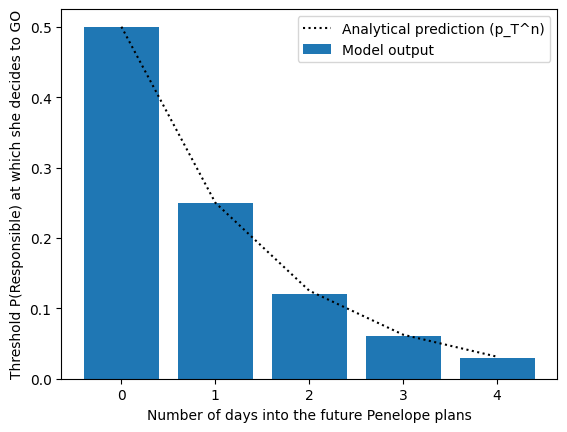

In [5]:
from matplotlib import pyplot as plt

ps = []
for n in range(5):
    z = day_model(n=n)
    p = P[np.where(z[:, 0] >= z[:, 1])[0][0]]
    ps.append(1 - p)

plt.plot(range(5), 1 / 2 ** (np.arange(5) + 1), c='k', ls=':', label='Analytical prediction (p_T^n)');
plt.bar(range(5), ps, label='Model output');

plt.xlabel('Number of days into the future Penelope plans')
plt.ylabel('Threshold P(Responsible) at which she decides to GO')
plt.legend();